Generative Pre-trained Transformer

In [2]:
import tiktoken
import torch
import torch.nn as nn
import urllib.request
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [3]:
url = "https://www.gutenberg.org/cache/epub/1041/pg1041.txt"
print("Downloading Shakespeare's Sonnets...")
try:
    with urllib.request.urlopen(url) as response:
        raw_text = response.read().decode('utf-8')
    
    print(f"Successfully downloaded! Total length: {len(raw_text)} characters.\n")
    
    start_marker = "THE SONNETS"
    start_idx = raw_text.find(start_marker)
    end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK"
    end_idx = raw_text.find(end_marker)

    if start_idx != -1 and end_idx != -1:
        raw_text = raw_text[start_idx:end_idx].strip()
    print("--- FIRST 3 SONNET LINES ---")
    lines = raw_text.split('\n')
    for line in lines[40:55]:
        print(line)
except Exception as e:
    print(f"An error occurred: {e}")


Successfully downloaded! Total length: 118546 characters.

--- FIRST 3 SONNET LINES ---

III

Look in thy glass and tell the face thou viewest
Now is the time that face should form another;
Whose fresh repair if now thou not renewest,
Thou dost beguile the world, unbless some mother.
For where is she so fair whose unear’d womb
Disdains the tillage of thy husbandry?
Or who is he so fond will be the tomb,
Of his self-love to stop posterity?
Thou art thy mother’s glass and she in thee
Calls back the lovely April of her prime;
So thou through windows of thine age shalt see,
Despite of wrinkles this thy golden time.


In [4]:
corpus = raw_text[:150].strip()
print(f"Sample Corpus Details:\n{"="*30}\n{corpus}\n{"="*30}")

Sample Corpus Details:
THE SONNETS

by William Shakespeare




I

From fairest creatures we desire increase,
That thereby beauty’s rose might never die,
But as th


In [5]:
enc = tiktoken.encoding_for_model("gpt-4o")
token_ids = enc.encode(raw_text)
vocab_size = enc.max_token_value + 1

In [6]:
data_tensor = torch.tensor(token_ids, dtype=torch.long)

Batching

In [7]:
block_size = 128
batch_size = 16

n = int(0.9 * len(data_tensor))
train_data = data_tensor[:n]
val_data = data_tensor[n:]

def get_batch(device, split):
    data = train_data if split == "train" else val_data
    ix = torch.randint(0, len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i + block_size] for i in ix])
    y = torch.stack([data[i + 1:i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

Embeddings

In [8]:
embedding_dim = 64

Number of Heads

In [12]:
num_heads = 4

Rotary Positional Encoding

In [9]:
class RotaryPositionEmbedding(nn.Module):
    def __init__(self, dim, max_position_embeddings=2048, base=10000):
        super().__init__()
        self.dim = dim
        self.base = base
        inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer('inv_freq', inv_freq)
        self._set_cos_sin_cache(max_position_embeddings)
    
    def _set_cos_sin_cache(self, seq_len):
        self.max_seq_len_cached = seq_len
        t = torch.arange(seq_len, dtype=self.inv_freq.dtype)
        freqs = torch.einsum('i,j->ij', t, self.inv_freq)
        emb = torch.cat((freqs, freqs), dim=-1)

        self.register_buffer('cos_cached', emb.cos())
        self.register_buffer('sin_cached', emb.sin())
    
    def forward(self, q, k, seq_len=None):
        if seq_len is None:
            seq_len = q.shape[1]
        if seq_len > self.max_seq_len_cached:
            self._set_cos_sin_cache(seq_len)
        
        return (
            self.apply_rotary_pos_emb(q, self.cos_cached, self.sin_cached),
            self.apply_rotary_pos_emb(k, self.cos_cached, self.sin_cached)
        )
    
    def apply_rotary_pos_emb(self, x, cos, sin):
        batch, seq_len, num_heads, head_dim = x.shape

        x1 = x[..., : head_dim // 2]
        x2 = x[..., head_dim // 2 :]

        cos = cos[:seq_len, : head_dim // 2].unsqueeze(0).unsqueeze(2)
        sin = sin[:seq_len, : head_dim // 2].unsqueeze(0).unsqueeze(2)

        y1 = x1 * cos - x2 * sin
        y2 = x1 * sin + x2 * cos

        return torch.cat([y1, y2], dim=-1)

Attention

In [ ]:
class CausalAttention(nn.Module):
    def __init__(self, dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.dim = dim
        self.q = nn.Linear(dim, dim, bias=False)
        self.k = nn.Linear(dim, dim, bias=False)
        self.v = nn.Linear(dim, dim, bias=False)
        self.head_dim = dim // num_heads
        self.rope = RotaryPositionEmbedding(self.head_dim)
    
    def forward(self, x):
        B, T, C = x.shape
        Q = self.q(x).view(B, T, self.num_heads, self.head_dim)
        K = self.k(x).view(B, T, self.num_heads, self.head_dim)
        V = self.v(x).view(B, T, self.num_heads, self.head_dim)

        Q, K = self.rope(Q, K, seq_len=T)

        Q = Q.transpose(1, 2)
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)

        scores = (Q @ K.transpose(-2, -1)) * (self.head_dim ** -0.5)
        mask = torch.tril(torch.ones(T, T, device=x.device)).view(1, T, T)

        scores = scores.masked_fill(mask == 0, float('-inf'))
        probs = F.softmax(scores, dim=-1)
        out = probs @ V
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return out

Transformer

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads):
        super().__init__()
        self.ln1 = nn.LayerNorm(dim)
        self.attn = CausalAttention(dim, num_heads)
        self.ln2 = nn.LayerNorm(dim)
        self.ffn = nn.Sequential(
            nn.Linear(dim, 4 * dim),
            nn.ReLU(),
            nn.Linear(4 * dim, dim)
        )
    
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x

Language head

In [11]:
class TinyGPT(nn.Module):
    def __init__(self, vocab_size, dim, num_heads):
        super().__init__()
        self.vocab_size = vocab_size
        self.token_emb = nn.Embedding(vocab_size, dim)
        self.block = TransformerBlock(dim, num_heads)
        self.ln_f = nn.LayerNorm(dim)
        self.lm_head = nn.Linear(dim, vocab_size)
    
    def forward(self, idx, targets=None):
        B, T = idx.shape

        tok_vectors = self.token_emb(idx)
        x = tok_vectors

        x = self.block(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.reshape(-1, self.vocab_size), targets.reshape(-1))
        
        return logits, loss

Training

In [13]:
@torch.no_grad()
def estimate_loss(model, device, eval_iters=20):
    out = {}
    model.eval()

    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)

        for k in range(eval_iters):
            x_batch, y_batch = get_batch(device, split)
            logits, loss = model(x_batch, y_batch)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TinyGPT(vocab_size, embedding_dim, num_heads).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
max_iters = 400 # 400 for best t loss and val loss # 3000
eval_interval = 100
train_loss_history = {}
val_loss_history = {}

for step in range(max_iters):
    x_batch, y_batch = get_batch(device, "train")
    logits, loss = model(x_batch, y_batch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % eval_interval == 0:
        losses = estimate_loss(model, device)
        train_loss_history[step] = losses["train"]
        val_loss_history[step] = losses["val"]
        print(f"Step {step:4d} | Train Loss: {losses['train']:.5f} | Val Loss: {losses['val']:.5f}")

Step    0 | Train Loss: 12.34444 | Val Loss: 12.34270


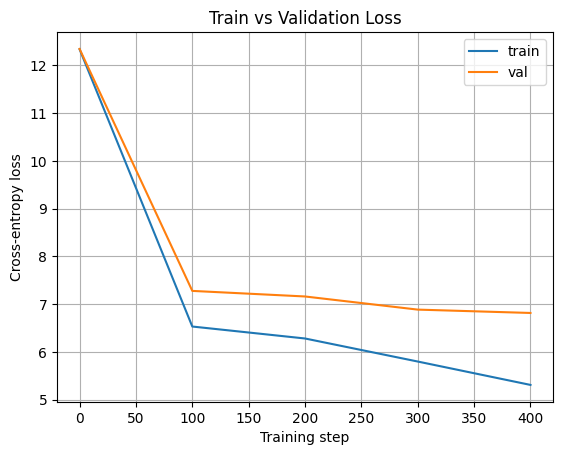

In [ ]:
plt.plot(train_loss_history.keys(), train_loss_history.values(), label="train")
plt.plot(val_loss_history.keys(), val_loss_history.values(), label="val")

plt.xlabel("Training step")
plt.ylabel("Cross-entropy loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model.eval()
with torch.no_grad():
    seed_token = token_ids[0]
    generated_indices = [seed_token]
    max_new_tokens = 100

    for _ in range(max_new_tokens):
        context = generated_indices[-block_size:]
        input_tensor = torch.tensor([context], dtype=torch.long, device=device)
        logits, _ = model(input_tensor)

        next_token = torch.argmax(logits[0, -1, :]).item()
        generated_indices.append(next_token)
    
    print("="*30, "\n", "Original Corpus", "\n", "="*30, "\n", corpus, "\n", "="*30, "\n")
    print("="*30, "\n", "Generated Corpus", "\n", "="*30, "\n", enc.decode(generated_indices), "\n", "="*30)

 Original Corpus 
 THE SONNETS

by William Shakespeare




I

From fairest creatures we desire increase,
That thereby beauty’s rose might never die,
But as th 

 Generated Corpus 
 THE,
And to the world of thyself, and,
    And to thee, and
Of the world, and thine, and thyself thyself’s day,
And for my love, and
The eyes of thyself thyself, and thine, and
The eyes,
And for my love, and thyself thyself thyself thyself, and thine,
And do not to the world, and,
    And of thyself, and thine,
    And the world 


Prompted next-token generation

In [ ]:
def generate_text(model, prompt, max_new_tokens=20):
    model.eval()
    generated_indices = enc.encode(prompt)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            context = generated_indices[-block_size:]
            input_tensor = torch.tensor([context], dtype=torch.long, device=device)
            logits, _ = model(input_tensor)
            next_token_logits = logits[0, -1, :]
            next_token = torch.argmax(next_token_logits).item()
            generated_indices.append(next_token)
    return enc.decode(generated_indices)


In [ ]:
prompt = "To be or not to be"
print(generate_text(model, prompt, max_new_tokens=20))

To be or not to beauteous,
And yet’d,
And for my love, and
    And the world,
